In [1]:
# ─────────────────────────────────────────────
# [C1] ◀ Part 0 · ⚙️ 환경 설정과 실습 데이터 환경 준비 — 라이브러리 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
!pip install scikit-learn xgboost matplotlib seaborn -q
import platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import matplotlib.font_manager as fm

# 한글 폰트 설정 — 그래프의 한글이 □□□로 깨지지 않게 합니다
system = platform.system()
if system == "Darwin":                      # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                                        # 코랩 등 리눅스 — 나눔고딕을 설치해야 합니다
    if not any("Nanum" in f.name for f in fm.fontManager.ttflist):
        print("나눔고딕을 설치합니다 (10~20초 걸립니다)...")
        import subprocess
        subprocess.run("apt-get install -y -qq fonts-nanum", shell=True,
                       capture_output=True)
        for path in fm.findSystemFonts(fontpaths=["/usr/share/fonts/truetype/nanum"]):
            fm.fontManager.addfont(path)
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"])

import sklearn, xgboost
print("준비 완료 ✓")
print(f"- scikit-learn {sklearn.__version__}")
print(f"- xgboost      {xgboost.__version__}")

준비 완료 ✓
- scikit-learn 1.9.0
- xgboost      3.2.0


In [2]:
# ─────────────────────────────────────────────
# [C2] ◀ Part 0 · ⚙️ 환경 설정과 실습 데이터 데이터 로드 — 분류(유방암) + 회귀(당뇨), 전부 sklearn 내장 (인터넷 불필요)
# ─────────────────────────────────────────────
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 메인 분류 데이터: 유방암 진단 (이진분류) — 🎬 오늘의 무대에서 소개한 공개 실습 데이터
cancer = load_breast_cancer(as_frame=True)
Xc, yc = cancer.data, cancer.target
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    Xc, yc, test_size=0.2, random_state=RANDOM_STATE, stratify=yc)

print(f"분류 데이터(유방암): 학습 {Xc_tr.shape[0]} / 테스트 {Xc_te.shape[0]} | 피처 {Xc.shape[1]}개")
print(f"  클래스: {dict(zip(['악성(0)','양성(1)'], np.bincount(yc)))}")

분류 데이터(유방암): 학습 455 / 테스트 114 | 피처 30개
  클래스: {'악성(0)': np.int64(212), '양성(1)': np.int64(357)}


In [3]:
# ─────────────────────────────────────────────
# [C2] Part 0 · ⚙️ 환경 설정과 실습 데이터
# 데이터 로드와 분할 — 지난 시간과 동일 (실행하면 크기와 클래스 비율이 나옵니다)
# ─────────────────────────────────────────────
X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

print(f"전체 {X.shape[0]}명 × 피처 {X.shape[1]}개")
print(f"  양성(1) 비율 {y.mean():.3f}   ← 비교적 균형 잡힌 데이터입니다")
print()
print(f"학습 {len(X_train)}명 / 테스트 {len(X_test)}명")
print(f"  학습 양성 비율 {y_train.mean():.3f} / 테스트 양성 비율 {y_test.mean():.3f}")
print()
print("→ stratify=y 덕분에 두 쪽의 클래스 비율이 거의 같습니다.")
print("  이 옵션이 왜 중요한지는 Part 4에서 정면으로 다룹니다.")

전체 569명 × 피처 30개
  양성(1) 비율 0.627   ← 비교적 균형 잡힌 데이터입니다

학습 426명 / 테스트 143명
  학습 양성 비율 0.627 / 테스트 양성 비율 0.629

→ stratify=y 덕분에 두 쪽의 클래스 비율이 거의 같습니다.
  이 옵션이 왜 중요한지는 Part 4에서 정면으로 다룹니다.


In [4]:
# ─────────────────────────────────────────────
# [C3] Part 1 · 📊 데이터로 확인해 봅시다 — 시드만 바꿔 열 번
# random_state만 0~9로 바꿔 같은 실험 반복 (실행하면 열 개의 점수와 폭이 나옵니다)
# ─────────────────────────────────────────────
scores_holdout = []
for seed in range(10):
    Xa, Xb, ya, yb = train_test_split(
        X, y, test_size=0.1, random_state=seed, stratify=y)
    m = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    ).fit(Xa, ya)
    scores_holdout.append(m.score(Xb, yb))

scores_holdout = np.array(scores_holdout)

print("random_state별 테스트 정확도")
for seed, s in enumerate(scores_holdout):
    bar = "█" * int((s - 0.95) * 400)      # 0.95를 기준으로 확대해 차이를 보이게
    print(f"  seed={seed}  {s:.3f}  {bar}")
print()
print(f"최소 {scores_holdout.min():.3f} / 최대 {scores_holdout.max():.3f}"
      f" → 폭 {scores_holdout.max() - scores_holdout.min():.3f}")
print(f"평균 {scores_holdout.mean():.3f} ± {scores_holdout.std():.3f}")
print()
print("→ 모델도 데이터도 똑같습니다. 바꾼 것은 '어떻게 나눌지'뿐입니다.")

random_state별 테스트 정확도
  seed=0  0.982  ████████████
  seed=1  0.982  ████████████
  seed=2  1.000  ████████████████████
  seed=3  0.982  ████████████
  seed=4  1.000  ████████████████████
  seed=5  0.982  ████████████
  seed=6  0.982  ████████████
  seed=7  0.982  ████████████
  seed=8  0.965  █████
  seed=9  1.000  ████████████████████

최소 0.965 / 최대 1.000 → 폭 0.035
평균 0.986 ± 0.011

→ 모델도 데이터도 똑같습니다. 바꾼 것은 '어떻게 나눌지'뿐입니다.


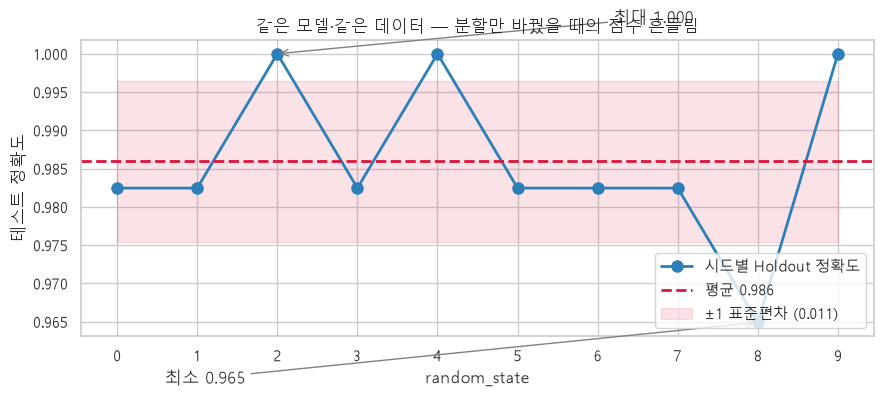

→ 붉은 띠(±1 표준편차) 밖으로 점이 튀어나가는 것을 보세요. 한 점만 보고하면 그 점이 어디였는지에 운이 좌우합니다.


In [5]:
# ─────────────────────────────────────────────
# [C4] Part 1 · 📊 데이터로 확인해 봅시다 — 시드만 바꿔 열 번
# 흔들림을 그림으로 — 점수 분포와 평균±표준편차 (실행하면 그래프가 그려집니다)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.2))

ax.plot(range(10), scores_holdout, "o-", lw=2, markersize=8,
        color="#2c7fb8", label="시드별 Holdout 정확도")
mean_, std_ = scores_holdout.mean(), scores_holdout.std()
ax.axhline(mean_, color="crimson", ls="--", lw=2, label=f"평균 {mean_:.3f}")
ax.fill_between(range(10), mean_ - std_, mean_ + std_, color="crimson", alpha=0.12,
                label=f"±1 표준편차 ({std_:.3f})")
ax.annotate(f"최대 {scores_holdout.max():.3f}",
            xy=(int(np.argmax(scores_holdout)), scores_holdout.max()),
            xytext=(6.2, scores_holdout.max() + 0.004),
            arrowprops=dict(arrowstyle="->", color="gray"))
ax.annotate(f"최소 {scores_holdout.min():.3f}",
            xy=(int(np.argmin(scores_holdout)), scores_holdout.min()),
            xytext=(0.6, scores_holdout.min() - 0.008),
            arrowprops=dict(arrowstyle="->", color="gray"))

ax.set_xlabel("random_state")
ax.set_ylabel("테스트 정확도")
ax.set_title("같은 모델·같은 데이터 — 분할만 바꿨을 때의 점수 흔들림")
ax.set_xticks(range(10))
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("→ 붉은 띠(±1 표준편차) 밖으로 점이 튀어나가는 것을 보세요. 한 점만 보고하면 그 점이 어디였는지에 운이 좌우합니다.")

In [10]:
# ─────────────────────────────────────────────
# [C6] Part 2 · 📊 데이터로 확인해 봅시다 — 과적합이 태어나는 장면
# 트리 깊이를 키우며 학습/테스트 점수 추적 (실행하면 깊이별 격차 표가 나옵니다)
# ─────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
depths = [1, 2, 3, 5, 8, 12, None]

rows = []
for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    tree.fit(X_train, y_train)
    tr = tree.score(X_train, y_train)
    te = tree.score(X_test, y_test)
    rows.append({
        "max_depth": "제한 없음" if d is None else d,
        "학습 점수": tr,
        "테스트 점수": te,
        "격차": tr - te,
        "실제 깊이": tree.get_depth(),
    })
gap = pd.DataFrame(rows)
print(gap.round(3).to_string(index=False))
print()
best = gap.loc[gap["테스트 점수"].idxmax()]
print(f"→ 테스트 점수가 가장 높은 설정: max_depth={best['max_depth']} (테스트 {best['테스트 점수']:.3f})")
print(f"  학습 점수가 1.000이 되는 지점부터 테스트는 {gap['테스트 점수'].iloc[-1]:.3f}에 머물고 격차만 벌어집니다.")

max_depth  학습 점수  테스트 점수     격차  실제 깊이
        1  0.923   0.923 -0.001      1
        2  0.958   0.909  0.049      2
        3  0.977   0.944  0.032      3
        5  0.995   0.937  0.058      5
        8  1.000   0.923  0.077      7
       12  1.000   0.923  0.077      7
    제한 없음  1.000   0.923  0.077      7

→ 테스트 점수가 가장 높은 설정: max_depth=3 (테스트 0.944)
  학습 점수가 1.000이 되는 지점부터 테스트는 0.923에 머물고 격차만 벌어집니다.


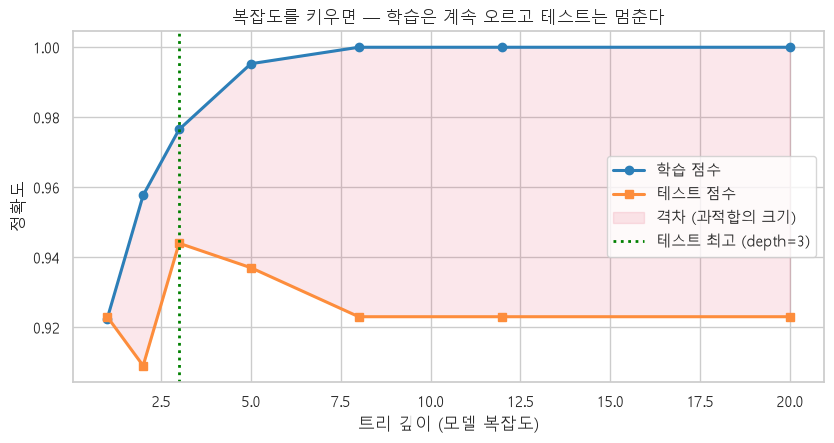

→ 붉은 영역이 넓어지는 것이 곧 과적합이 자라는 모습입니다.
  녹색 점선 왼쪽은 과소적합 영역, 오른쪽은 과적합 영역입니다.


In [7]:
# ─────────────────────────────────────────────
# [C7] Part 2 · 📊 데이터로 확인해 봅시다 — 과적합이 태어나는 장면
# 격차가 벌어지는 모습을 그림으로 (실행하면 두 곡선과 격차 영역이 그려집니다)
# ─────────────────────────────────────────────
plot_depths = [1, 2, 3, 5, 8, 12, 20]
tr_scores, te_scores = [], []
for d in plot_depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE).fit(X_train, y_train)
    tr_scores.append(t.score(X_train, y_train))
    te_scores.append(t.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(plot_depths, tr_scores, "o-", lw=2.2, color="#2c7fb8", label="학습 점수")
ax.plot(plot_depths, te_scores, "s-", lw=2.2, color="#fd8d3c", label="테스트 점수")
ax.fill_between(plot_depths, te_scores, tr_scores, color="crimson", alpha=0.10,
                label="격차 (과적합의 크기)")
best_i = int(np.argmax(te_scores))
ax.axvline(plot_depths[best_i], color="green", ls=":", lw=2,
           label=f"테스트 최고 (depth={plot_depths[best_i]})")
ax.set_xlabel("트리 깊이 (모델 복잡도)")
ax.set_ylabel("정확도")
ax.set_title("복잡도를 키우면 — 학습은 계속 오르고 테스트는 멈춘다")
ax.legend(loc="center right")
plt.tight_layout()
plt.show()

print("→ 붉은 영역이 넓어지는 것이 곧 과적합이 자라는 모습입니다.")
print(f"  녹색 점선 왼쪽은 과소적합 영역, 오른쪽은 과적합 영역입니다.")

In [8]:
# ─────────────────────────────────────────────
# [C8] Part 2 · ➕ 더 알고 싶다면 — 규제(Regularization)로 과적합 억제
# 규제 세기 C를 바꿔가며 학습/테스트 점수와 계수 크기 관찰 (실행하면 표가 나옵니다)
# ─────────────────────────────────────────────
rows = []
for C_val in [0.001, 0.01, 0.1, 1, 10, 100]:
    m = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=C_val, max_iter=5000, random_state=RANDOM_STATE),
    ).fit(X_train, y_train)
    coef = m.named_steps["logisticregression"].coef_[0]
    rows.append({
        "C (작을수록 강한 규제)": C_val,
        "학습 점수": m.score(X_train, y_train),
        "테스트 점수": m.score(X_test, y_test),
        "|계수| 합": np.abs(coef).sum(),
    })
reg = pd.DataFrame(rows)
print(reg.round(3).to_string(index=False))
print()
best = reg.loc[reg["테스트 점수"].idxmax()]
print(f"→ 테스트 최고: C={best['C (작을수록 강한 규제)']} (테스트 {best['테스트 점수']:.3f})")
print("  규제를 풀면(C↑) 계수가 커지고 학습 점수는 오르지만 테스트는 떨어집니다.")

 C (작을수록 강한 규제)  학습 점수  테스트 점수  |계수| 합
          0.001  0.892   0.916   1.390
          0.010  0.958   0.937   3.949
          0.100  0.984   0.979   8.599
          1.000  0.988   0.986  16.789
         10.000  0.991   0.972  35.230
        100.000  0.998   0.944 114.147

→ 테스트 최고: C=1.0 (테스트 0.986)
  규제를 풀면(C↑) 계수가 커지고 학습 점수는 오르지만 테스트는 떨어집니다.


In [9]:
# ─────────────────────────────────────────────
# [C9] Part 2 · ➕ 더 알고 싶다면 — 규제(Regularization)로 과적합 억제
# L1(Lasso) vs L2(Ridge) — 계수가 0이 되는 개수 비교 (실행하면 비교표가 나옵니다)
# ─────────────────────────────────────────────
rows = []
for C_val in [0.001, 0.01, 0.1, 1, 10]:
    out = {"C": C_val}
    # l1_ratio=1 → L1(Lasso), 0 → L2(Ridge). 구 penalty= 인자는 sklearn 1.10에서 제거됩니다
    for l1_ratio, label in [(1.0, "L1(Lasso)"), (0.0, "L2(Ridge)")]:
        m = make_pipeline(
            StandardScaler(),
            LogisticRegression(C=C_val, l1_ratio=l1_ratio, solver="saga",
                               max_iter=20000, random_state=RANDOM_STATE),
        ).fit(X_train, y_train)
        coef = m.named_steps["logisticregression"].coef_[0]
        out[f"{label} 0인 피처"] = int((np.abs(coef) < 1e-8).sum())
        out[f"{label} 테스트"] = m.score(X_test, y_test)
    rows.append(out)
paths = pd.DataFrame(rows)
print(f"전체 피처 {X.shape[1]}개 중 계수가 0이 된 개수")
print()
print(paths.round(3).to_string(index=False))
print()
print("→ L1은 규제를 세게 걸수록 많은 피처를 '완전히 끕니다'(계수 0). L2는 한 개도 끄지 않습니다.")

전체 피처 30개 중 계수가 0이 된 개수

     C  L1(Lasso) 0인 피처  L1(Lasso) 테스트  L2(Ridge) 0인 피처  L2(Ridge) 테스트
 0.001               30          0.629                0          0.916
 0.010               27          0.867                0          0.937
 0.100               23          0.965                0          0.979
 1.000               14          0.993                0          0.986
10.000                4          0.979                0          0.972

→ L1은 규제를 세게 걸수록 많은 피처를 '완전히 끕니다'(계수 0). L2는 한 개도 끄지 않습니다.


In [11]:
# [C10] Part 2 · ⌨️ 백문이 불여일타! (2)
# ⌨️ 백문이 불여일타! (2) — 다른 손잡이(min_samples_leaf)로 과적합 억제

leaf_sizes = [1, 5, 10, 30, 50]

# 여기에 코드를 작성하세요
rows = []
for n in leaf_sizes:
    tree = DecisionTreeClassifier(min_samples_leaf=n, random_state=RANDOM_STATE)
    tree.fit(X_train, y_train)
    tr = tree.score(X_train, y_train)
    te = tree.score(X_test, y_test)
    rows.append({
        "min_samples_leaf": n,
        "학습 점수": tr,
        "테스트 점수": te,
        "격차": tr - te,
        "실제 깊이": tree.get_depth(),
    })
gap = pd.DataFrame(rows)
print(gap.round(3).to_string(index=False))
print()
best = gap.loc[gap["테스트 점수"].idxmax()]
print(f"→ 테스트 점수가 가장 높은 설정: min_samples_leaf={best['min_samples_leaf']} (테스트 {best['테스트 점수']:.3f})")
print(f"  학습 점수가 1.000이 되는 지점부터 테스트는 {gap['테스트 점수'].iloc[-1]:.3f}에 머물고 격차만 벌어집니다.")

 min_samples_leaf  학습 점수  테스트 점수     격차  실제 깊이
                1  1.000   0.923  0.077      7
                5  0.977   0.930  0.046      6
               10  0.962   0.951  0.011      5
               30  0.946   0.916  0.030      4
               50  0.923   0.923 -0.001      3

→ 테스트 점수가 가장 높은 설정: min_samples_leaf=10.0 (테스트 0.951)
  학습 점수가 1.000이 되는 지점부터 테스트는 0.923에 머물고 격차만 벌어집니다.


1. min_samples_leaf가 과적합을 억제하는 이유
  - min_samples_leaf은 한 두명만 보고 규칙을 만들지 말고 최소한 n명정도는 보고 규칙을 만들어라 라고 하는것과 같다
  그렇다고 또 너무 키워버리면 트리가 아주 깊이 못들어가고 멈춰버린다 - 모델이 세밀한 패턴을 학습하지 못한다
  요약하면 1일때는 과적합을, 50일때는 과소적합을 해버린것이다.

In [12]:
# ─────────────────────────────────────────────
# [C11] Part 3 · 📊 데이터로 확인해 봅시다 — 우리 데이터는 어느 구간인가
# 학습곡선 계산 — 데이터 양을 늘려가며 학습/검증 점수 (실행하면 단계별 표가 나옵니다)
# ─────────────────────────────────────────────
from sklearn.model_selection import StratifiedKFold, learning_curve
model_lc = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
)

train_sizes, train_scores, val_scores = learning_curve(
    model_lc, X, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    train_sizes=np.linspace(0.1, 1.0, 6),
    scoring="accuracy",
)

lc = pd.DataFrame({
    "학습 표본 수": train_sizes.astype(int),
    "학습 점수": train_scores.mean(axis=1),
    "검증 점수": val_scores.mean(axis=1),
})
lc["격차"] = lc["학습 점수"] - lc["검증 점수"]
lc["검증 점수 증가분"] = lc["검증 점수"].diff().fillna(0)

print(lc.round(3).to_string(index=False))
print()
last_gain = lc["검증 점수 증가분"].iloc[-1]
print(f"→ 마지막 구간(표본 {int(train_sizes[-2])}→{int(train_sizes[-1])})의 검증 점수 변화: {last_gain:+.3f}")
print("  이 값이 0에 가까우면 '데이터를 더 모아도 이득이 거의 없다'는 신호입니다.")

 학습 표본 수  학습 점수  검증 점수    격차  검증 점수 증가분
      45  0.987  0.859 0.127      0.000
     127  0.983  0.954 0.028      0.095
     209  0.987  0.970 0.016      0.016
     291  0.982  0.967 0.015     -0.004
     373  0.987  0.977 0.010      0.011
     455  0.988  0.974 0.014     -0.004

→ 마지막 구간(표본 373→455)의 검증 점수 변화: -0.004
  이 값이 0에 가까우면 '데이터를 더 모아도 이득이 거의 없다'는 신호입니다.


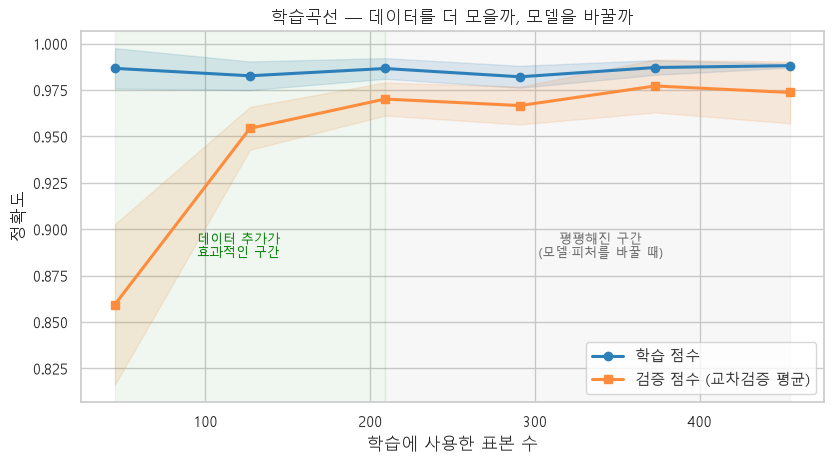

→ 주황 선(검증)의 오른쪽 끝이 평평하면 데이터 추가의 이득이 거의 없다는 뜻입니다.


In [13]:
# ─────────────────────────────────────────────
# [C12] Part 3 · 📊 데이터로 확인해 봅시다 — 우리 데이터는 어느 구간인가
# 학습곡선 그리기 — 흔들림 범위까지 함께 (실행하면 두 곡선과 신뢰 띠가 그려집니다)
# ─────────────────────────────────────────────
tr_mean, tr_std = train_scores.mean(axis=1), train_scores.std(axis=1)
va_mean, va_std = val_scores.mean(axis=1), val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(train_sizes, tr_mean, "o-", lw=2.2, color="#2c7fb8", label="학습 점수")
ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, color="#2c7fb8", alpha=0.15)
ax.plot(train_sizes, va_mean, "s-", lw=2.2, color="#fd8d3c", label="검증 점수 (교차검증 평균)")
ax.fill_between(train_sizes, va_mean - va_std, va_mean + va_std, color="#fd8d3c", alpha=0.15)

ax.axvspan(train_sizes[0], 209, color="green", alpha=0.06)
ax.text(120, 0.885, "데이터 추가가\n효과적인 구간", ha="center", fontsize=9, color="green")
ax.axvspan(209, train_sizes[-1], color="gray", alpha=0.06)
ax.text(340, 0.885, "평평해진 구간\n(모델·피처를 바꿀 때)", ha="center", fontsize=9, color="dimgray")

ax.set_xlabel("학습에 사용한 표본 수")
ax.set_ylabel("정확도")
ax.set_title("학습곡선 — 데이터를 더 모을까, 모델을 바꿀까")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("→ 주황 선(검증)의 오른쪽 끝이 평평하면 데이터 추가의 이득이 거의 없다는 뜻입니다.")

In [14]:
# ─────────────────────────────────────────────
# [C11] Part 3 · 📊 데이터로 확인해 봅시다 — 우리 데이터는 어느 구간인가
# 학습곡선 계산 — 데이터 양을 늘려가며 학습/검증 점수 (실행하면 단계별 표가 나옵니다)
# ─────────────────────────────────────────────
from sklearn.model_selection import StratifiedKFold, learning_curve
model_lc = make_pipeline(
    StandardScaler(),
    DecisionTreeClassifier(random_state=RANDOM_STATE),
)

train_sizes, train_scores, val_scores = learning_curve(
    model_lc, X, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    train_sizes=np.linspace(0.1, 1.0, 6),
    scoring="accuracy",
)

lc = pd.DataFrame({
    "학습 표본 수": train_sizes.astype(int),
    "학습 점수": train_scores.mean(axis=1),
    "검증 점수": val_scores.mean(axis=1),
})
lc["격차"] = lc["학습 점수"] - lc["검증 점수"]
lc["검증 점수 증가분"] = lc["검증 점수"].diff().fillna(0)

print(lc.round(3).to_string(index=False))
print()
last_gain = lc["검증 점수 증가분"].iloc[-1]
print(f"→ 마지막 구간(표본 {int(train_sizes[-2])}→{int(train_sizes[-1])})의 검증 점수 변화: {last_gain:+.3f}")
print("  이 값이 0에 가까우면 '데이터를 더 모아도 이득이 거의 없다'는 신호입니다.")

 학습 표본 수  학습 점수  검증 점수    격차  검증 점수 증가분
      45    1.0  0.810 0.190      0.000
     127    1.0  0.877 0.123      0.067
     209    1.0  0.910 0.090      0.033
     291    1.0  0.896 0.104     -0.014
     373    1.0  0.909 0.091      0.012
     455    1.0  0.910 0.090      0.002

→ 마지막 구간(표본 373→455)의 검증 점수 변화: +0.002
  이 값이 0에 가까우면 '데이터를 더 모아도 이득이 거의 없다'는 신호입니다.


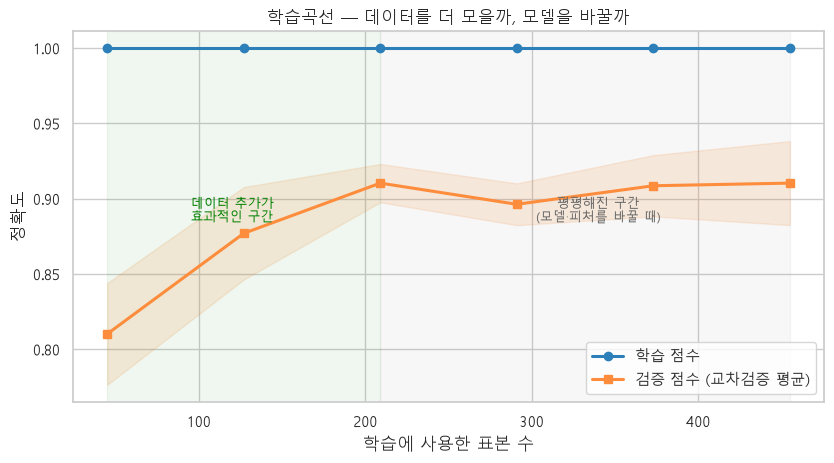

→ 주황 선(검증)의 오른쪽 끝이 평평하면 데이터 추가의 이득이 거의 없다는 뜻입니다.


In [15]:
# ─────────────────────────────────────────────
# [C12] Part 3 · 📊 데이터로 확인해 봅시다 — 우리 데이터는 어느 구간인가
# 학습곡선 그리기 — 흔들림 범위까지 함께 (실행하면 두 곡선과 신뢰 띠가 그려집니다)
# ─────────────────────────────────────────────
tr_mean, tr_std = train_scores.mean(axis=1), train_scores.std(axis=1)
va_mean, va_std = val_scores.mean(axis=1), val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(train_sizes, tr_mean, "o-", lw=2.2, color="#2c7fb8", label="학습 점수")
ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, color="#2c7fb8", alpha=0.15)
ax.plot(train_sizes, va_mean, "s-", lw=2.2, color="#fd8d3c", label="검증 점수 (교차검증 평균)")
ax.fill_between(train_sizes, va_mean - va_std, va_mean + va_std, color="#fd8d3c", alpha=0.15)

ax.axvspan(train_sizes[0], 209, color="green", alpha=0.06)
ax.text(120, 0.885, "데이터 추가가\n효과적인 구간", ha="center", fontsize=9, color="green")
ax.axvspan(209, train_sizes[-1], color="gray", alpha=0.06)
ax.text(340, 0.885, "평평해진 구간\n(모델·피처를 바꿀 때)", ha="center", fontsize=9, color="dimgray")

ax.set_xlabel("학습에 사용한 표본 수")
ax.set_ylabel("정확도")
ax.set_title("학습곡선 — 데이터를 더 모을까, 모델을 바꿀까")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("→ 주황 선(검증)의 오른쪽 끝이 평평하면 데이터 추가의 이득이 거의 없다는 뜻입니다.")

1. 학습점수가 항상 1에 가깝게 붙어있는 이유
  - max_depth가 없으면 트리는 항상 "더 이상 나눌게 없을때까지" 자라는게 정지 조건, 그래서 train_size에 상관없이 전부 완벽하게 분류될때까지 쪼개버림
2. 그에 비해 검증점수는 요동치는 이유
  - 전형적인 과적합의 모습, 데이터가 바뀔때마다 값이 크게 바뀜(폴드가 바뀌거나, 샘플수가 바뀌면) - 분산이 크다

In [16]:
# ─────────────────────────────────────────────
# [C14] Part 4 · 📊 데이터로 확인해 봅시다 — 조각의 구성을 직접 들여다보기
# 세 가지 분할 방식의 fold별 클래스 비율 비교 (실행하면 조각별 양성 비율이 나옵니다)
# ─────────────────────────────────────────────
from sklearn.model_selection import KFold
splitters = [
    ("KFold (셔플 없음)", KFold(n_splits=5)),
    ("KFold (shuffle=True)", KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)),
    ("StratifiedKFold (shuffle=True)",
     StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)),
]

print(f"전체 양성 비율 = {y.mean():.3f}\n")
for name, sp in splitters:
    rates = [y[val_idx].mean() for _, val_idx in sp.split(X, y)]
    print(f"{name}")
    print(f"  조각별 양성 비율 {[round(float(r), 3) for r in rates]}")
    print(f"  → 최대-최소 폭 {max(rates) - min(rates):.3f}")
    print()

전체 양성 비율 = 0.627

KFold (셔플 없음)
  조각별 양성 비율 [0.404, 0.57, 0.649, 0.746, 0.77]
  → 최대-최소 폭 0.366

KFold (shuffle=True)
  조각별 양성 비율 [0.623, 0.675, 0.623, 0.623, 0.593]
  → 최대-최소 폭 0.083

StratifiedKFold (shuffle=True)
  조각별 양성 비율 [0.623, 0.623, 0.632, 0.632, 0.628]
  → 최대-최소 폭 0.009



In [18]:
# ─────────────────────────────────────────────
# [C15] Part 4 · 📊 데이터로 확인해 봅시다 — 조각의 구성을 직접 들여다보기
# 분할 방식이 실제 점수에 미치는 영향 + 다중 지표 동시 교차검증
# (실행하면 방식별 점수와 지표 5종이 나옵니다)
# ─────────────────────────────────────────────
from sklearn.model_selection import cross_val_score, cross_validate
print("① 분할 방식이 최종 점수를 얼마나 바꾸나")
for name, sp in splitters:
    s = cross_val_score(model_lc, X, y, cv=sp, scoring="accuracy")
    print(f"  {name:32} {s.mean():.4f} ± {s.std():.4f}")

print()
print("② 한 번에 여러 지표로 교차검증 (StratifiedKFold 5겹)")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
result = cross_validate(model_lc, X, y, cv=cv,
                        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"])

rows = []
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    arr = result["test_" + metric]
    rows.append({"지표": metric, "평균": arr.mean(), "표준편차": arr.std(),
                 "보고 형식": f"{arr.mean():.3f} ± {arr.std():.3f}"})
multi = pd.DataFrame(rows)
print(multi.round(4).to_string(index=False))

① 분할 방식이 최종 점수를 얼마나 바꾸나
  KFold (셔플 없음)                    0.9120 ± 0.0436
  KFold (shuffle=True)             0.9332 ± 0.0162
  StratifiedKFold (shuffle=True)   0.9104 ± 0.0279

② 한 번에 여러 지표로 교차검증 (StratifiedKFold 5겹)
       지표     평균   표준편차         보고 형식
 accuracy 0.9104 0.0279 0.910 ± 0.028
precision 0.9197 0.0393 0.920 ± 0.039
   recall 0.9412 0.0101 0.941 ± 0.010
       f1 0.9299 0.0204 0.930 ± 0.020
  roc_auc 0.9000 0.0368 0.900 ± 0.037


- 조각구성은 전체 양성율과 매우 차이가 났는데 최종 점수는 세 방식이 거의 같음
- 이유는 이 데이터가 로지스틱 회귀와 굉장히 잘 맞기 떄문이다.
- 보고서를 작성할때는 5가지 지표 모두 평균 + 표준편차로 적으면 된다

In [19]:
# ─────────────────────────────────────────────
# [C16] Part 4 · 데이터로 확인 — 지난 시간 모델들을 다시 채점하기
# Holdout 1회 vs 계층 5겹 CV — 순서 2 모델 4종 재추정 (실행하면 비교표가 나옵니다)
# ─────────────────────────────────────────────
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
candidates = {
    "LogisticRegression": make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=3,
                             random_state=RANDOM_STATE, eval_metric="logloss"),
}

# 베이스라인도 함께 — "이보다 나아야 모델"
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
print(f"베이스라인(다수 클래스 찍기) 정확도 = {dummy.score(X_test, y_test):.4f}\n")

rows = []
for name, m in candidates.items():
    m.fit(X_train, y_train)
    holdout = m.score(X_test, y_test)
    cv_scores = cross_val_score(m, X, y, cv=cv, scoring="accuracy")
    rows.append({
        "모델": name,
        "Holdout 1회": holdout,
        "CV 평균": cv_scores.mean(),
        "CV 표준편차": cv_scores.std(),
        "CV 보고 형식": f"{cv_scores.mean():.3f} ± {cv_scores.std():.3f}",
        "Holdout − CV": holdout - cv_scores.mean(),
    })
compare = pd.DataFrame(rows)
print(compare.round(4).to_string(index=False))
print()
print(f"Holdout 기준 1위: {compare.loc[compare['Holdout 1회'].idxmax(), '모델']}")
print(f"CV 기준 1위:      {compare.loc[compare['CV 평균'].idxmax(), '모델']}")
print(f"가장 불안정한 모델: {compare.loc[compare['CV 표준편차'].idxmax(), '모델']}"
      f" (± {compare['CV 표준편차'].max():.4f})")

베이스라인(다수 클래스 찍기) 정확도 = 0.6294

                모델  Holdout 1회  CV 평균  CV 표준편차      CV 보고 형식  Holdout − CV
LogisticRegression      0.9860 0.9737   0.0166 0.974 ± 0.017        0.0123
      DecisionTree      0.9231 0.9104   0.0279 0.910 ± 0.028        0.0127
      RandomForest      0.9580 0.9526   0.0131 0.953 ± 0.013        0.0055
           XGBoost      0.9650 0.9578   0.0117 0.958 ± 0.012        0.0072

Holdout 기준 1위: LogisticRegression
CV 기준 1위:      LogisticRegression
가장 불안정한 모델: DecisionTree (± 0.0279)


1. holdout 1회와 cv 평균의 순위는 같다
2. 모든 모델에서 holdout이 cv평균보다 높다. - random_state=42 분할이 모든 모델에 유리했던 분할?
3. 표준편차를 보면 결정트리가 가장 높다 이것이 cv에서 알수있는것
- Holdout 1회는 random_state=42가 우연히 만들어낸 "하필 쉬웠던 한 조각"의 점수일 뿐이고, CV 평균이야말로 여러 조각의 난이도를 골고루 반영한 믿을만한 값이다. random_state=42 자체는 딱히 "잘 분배됐다"고 볼 이유가 없고, 오히려 이번엔 다소 유리한 쪽으로 치우친 우연이었다고 봐야 한다. 그래서 실무에서는 seed 하나에 의존하지 않고 CV(여러 개의 다른 분배)로 검증하는 것이

In [25]:
# ─────────────────────────────────────────────
# [C11] Part 3 · 📊 데이터로 확인해 봅시다 — 우리 데이터는 어느 구간인가
# 학습곡선 계산 — 데이터 양을 늘려가며 학습/검증 점수 (실행하면 단계별 표가 나옵니다)
# ─────────────────────────────────────────────
k_values = [3, 5, 10, 20]
from sklearn.model_selection import StratifiedKFold
model_lc = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
)

all_rows = []
for k in k_values:
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)
    result = cross_validate(model_lc, X, y, cv=cv,
                            scoring=["accuracy", "precision", "recall", "f1", "roc_auc"])
    for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
        arr = result["test_" + metric]
        all_rows.append({
              "k": k, 
              "지표": metric, 
              "평균": arr.mean(), 
              "표준편차": arr.std(),
              "보고 형식": f"{arr.mean():.3f} ± {arr.std():.3f}"
              })
multi = pd.DataFrame(all_rows)
print("=" * 50)
print("K값별 교차검증 안정성 비교 (지표: accuracy)")
print("=" * 50)

acc_df = multi[multi["지표"] == "accuracy"].sort_values("k")
for _, row in acc_df.iterrows():
    print(f"K={int(row['k']):>2}  {row['보고 형식']}")

print()
best_k_row = acc_df.loc[acc_df["평균"].idxmax()]
most_stable_row = acc_df.loc[acc_df["표준편차"].idxmin()]
least_stable_row = acc_df.loc[acc_df["표준편차"].idxmax()]

print(f"평균 기준 최고: K={int(best_k_row['k'])} ({best_k_row['보고 형식']})")
print(f"가장 안정적:   K={int(most_stable_row['k'])} (표준편차 {most_stable_row['표준편차']:.4f})")
print(f"가장 불안정:   K={int(least_stable_row['k'])} (표준편차 {least_stable_row['표준편차']:.4f})")

print()
std_trend = acc_df["표준편차"].values
if all(std_trend[i] >= std_trend[i+1] for i in range(len(std_trend)-1)):
    print("경향: K가 커질수록 표준편차가 꾸준히 감소함")
elif all(std_trend[i] <= std_trend[i+1] for i in range(len(std_trend)-1)):
    print("경향: K가 커질수록 표준편차가 꾸준히 증가함")
else:
    print("경향: K에 따른 표준편차 변화가 일정하지 않음 (데이터/시드에 따른 변동)")


K값별 교차검증 안정성 비교 (지표: accuracy)
K= 3  0.975 ± 0.010
K= 5  0.974 ± 0.017
K=10  0.975 ± 0.020
K=20  0.979 ± 0.028

평균 기준 최고: K=20 (0.979 ± 0.028)
가장 안정적:   K=3 (표준편차 0.0099)
가장 불안정:   K=20 (표준편차 0.0282)

경향: K가 커질수록 표준편차가 꾸준히 증가함
